# CLB2 analysis
February 8, 2024

In this notebook, we use CLB2 to determine if the normalization successfully improves the deconvolution consistency between the two replicates as well as fixed the smoothing and residual norm calculations

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [236]:
# Let's test this scaling by looking at a gene's deconvolution
# We will look at CLB2 and see how the scaling affects the read counts of the raw data

from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
    load_yl_replicate2_rg1_alpha_vst_config
from cc_src.chromatin_model import ChromatinModel

config1 = load_yl_replicate1_rg1_alpha_vst_config()
config2 = load_yl_replicate2_rg1_alpha_vst_config()

gene_name = 'CLB2'
chrom1_model = ChromatinModel(config1)
chrom1_model.load_mnase_gene(gene_name, replicate=1)

chrom2_model = ChromatinModel(config2)
chrom2_model.load_mnase_gene(gene_name, replicate=2)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the unflattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the unflattened grid to be deconvolved is: (16, 27)
Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the unflattened grid to be deconvolved is: (15, 27)
Applying normalization using scaling matrix: output/mnase/rep2_len_scaling_3len_bins.csv
The shape of the unflattened grid to be deconvolved is: (15, 27)


In [283]:
def plot_comparison_normalized(chrom1_model):

    def plot_hist(hist):
        plt.imshow(hist, origin='lower', vmax=150, cmap='magma_r', aspect='auto')
        plt.xticks([])
        plt.yticks([])

    n = len(chrom1_model.times)

    plt.figure(figsize=(3, 6))
    for tp_idx in range(n):

        # Here is the raw data for timepoint 1
        plt.subplot(n, 2, 1+tp_idx*2)
        plot_hist(chrom1_model.unnormalized_all_hists[tp_idx])

        # Now, plot the normalized bins
        plt.subplot(n, 2, 1+tp_idx*2+1)
        plot_hist(chrom1_model.all_hists[tp_idx])


Text(0.5, 0.98, 'Replicate 1')

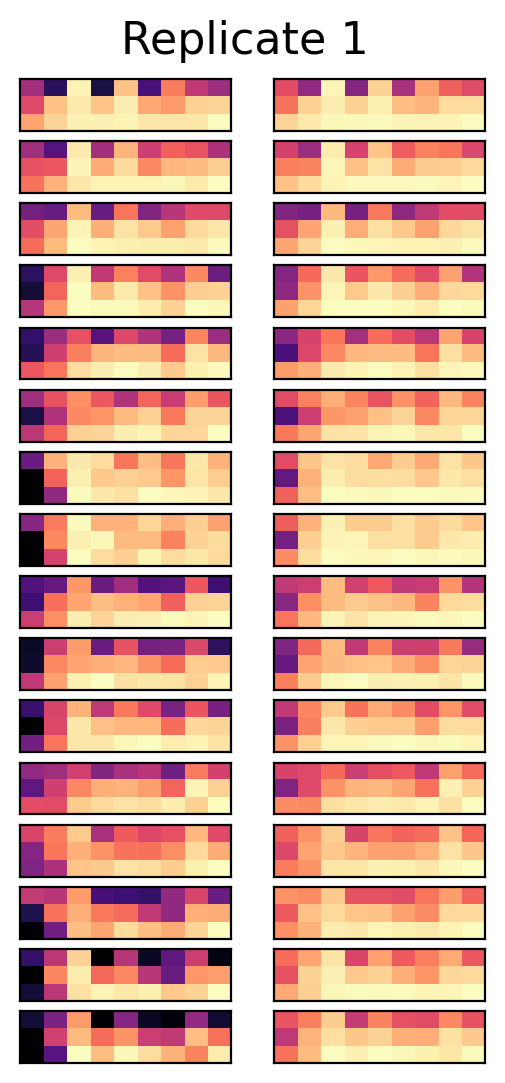

In [284]:
plot_comparison_normalized(chrom1_model)
plt.subplots_adjust(top=0.93)
plt.suptitle("Replicate 1", fontsize=16)

Text(0.5, 0.98, 'Replicate 2')

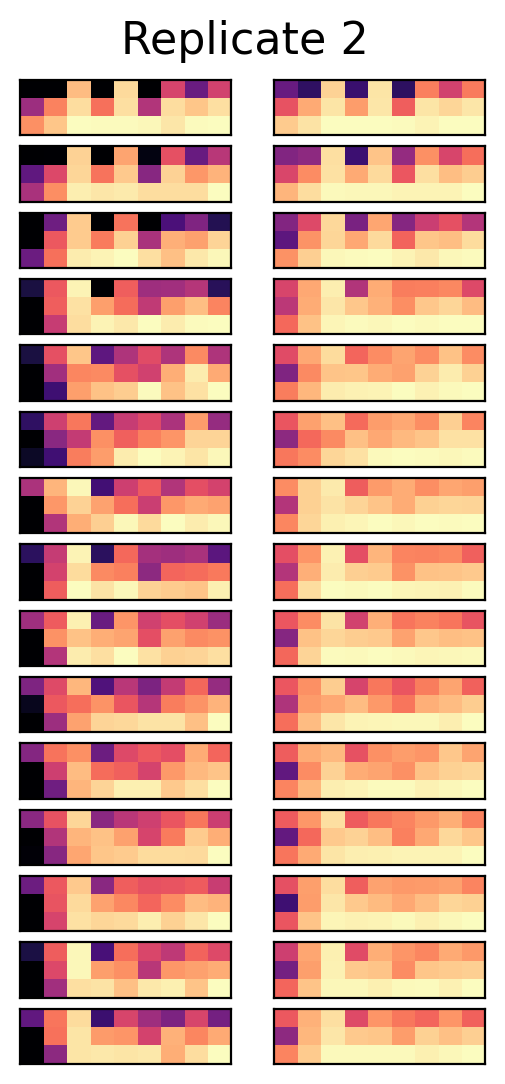

In [285]:
plot_comparison_normalized(chrom2_model)
plt.subplots_adjust(top=0.93)
plt.suptitle("Replicate 2", fontsize=16)

In [240]:
from src.model import Model

ge_model1 = Model(config1, gene_name)
ge_model1.deconvolve_find_optimal_gamma()

In [241]:
ge_model2 = Model(config2, gene_name)
ge_model2.deconvolve_find_optimal_gamma()

In [242]:
chrom1_model.deconvolve_find_optimal()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 0.8319
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 0.9119, rate = 9.6
  ...   gm = 0.0050, rn = 1.0323, rate = 24.09, time = 00:00:35.31
  ...   gm = 0.0026, rn = 0.9649, rate = 15.99, time = 00:00:43.95
  ...   gm = 0.0013, rn = 0.9233, rate = 10.99, time = 00:00:52.76
  ...  search right, rn_goal = 1.1647, rate = 40.0
  ... rn range: [0.9233, 1.1355]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 0.9233, rate = 10.99, time = 00:01:11.29
  ...   gm = 0.0022, rn = 0.9540, rate = 14.67, time = 00:01:20.00
  ...   gm = 0.0031, rn = 0.9810, rate = 17.92, time = 00:01:28.66
  ...   gm = 0.0039, rn = 1.0030, rate = 20.57, time = 00:01:37.65
  ...   gm = 0.0048, rn = 1.0257, rate = 23.29, time = 00:01:47.10
  ...   gm = 0.0057, rn = 1.0485, rate = 26.04, time = 00:01:56.14
  ...   gm = 0.0065, 

In [243]:
chrom2_model.deconvolve_find_optimal()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 0.3438
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 0.3782, rate = 10.0
  ...   gm = 0.0050, rn = 0.4457, rate = 29.63, time = 00:00:35.87
  ...   gm = 0.0026, rn = 0.4189, rate = 21.83, time = 00:00:44.55
  ...   gm = 0.0013, rn = 0.4008, rate = 16.57, time = 00:00:52.88
  ...  search right, rn_goal = 0.6638, rate = 93.1
  ... rn range: [0.4008, 0.5005]
  ... search gamma in [0.0013 0.0100] for elbow
  ...   gm = 0.0013, rn = 0.4008, rate = 16.57, time = 00:01:10.12
  ...   gm = 0.0022, rn = 0.4139, rate = 20.38, time = 00:01:18.86
  ...   gm = 0.0031, rn = 0.4249, rate = 23.58, time = 00:01:27.50
  ...   gm = 0.0039, rn = 0.4336, rate = 26.13, time = 00:01:36.11
  ...   gm = 0.0048, rn = 0.4428, rate = 28.80, time = 00:01:44.92
  ...   gm = 0.0057, rn = 0.4521, rate = 31.50, time = 00:01:53.89
  ...   gm = 0.0065,

In [272]:
# Precomputed gamma values, it takes about 3 minutes to compute the optimal gamma
# as we debug the fits
optimal_gamma1 = 0.00913
optimal_gamma2 = 0.00654

chrom1_model.gamma = optimal_gamma1
chrom2_model.gamma = optimal_gamma2

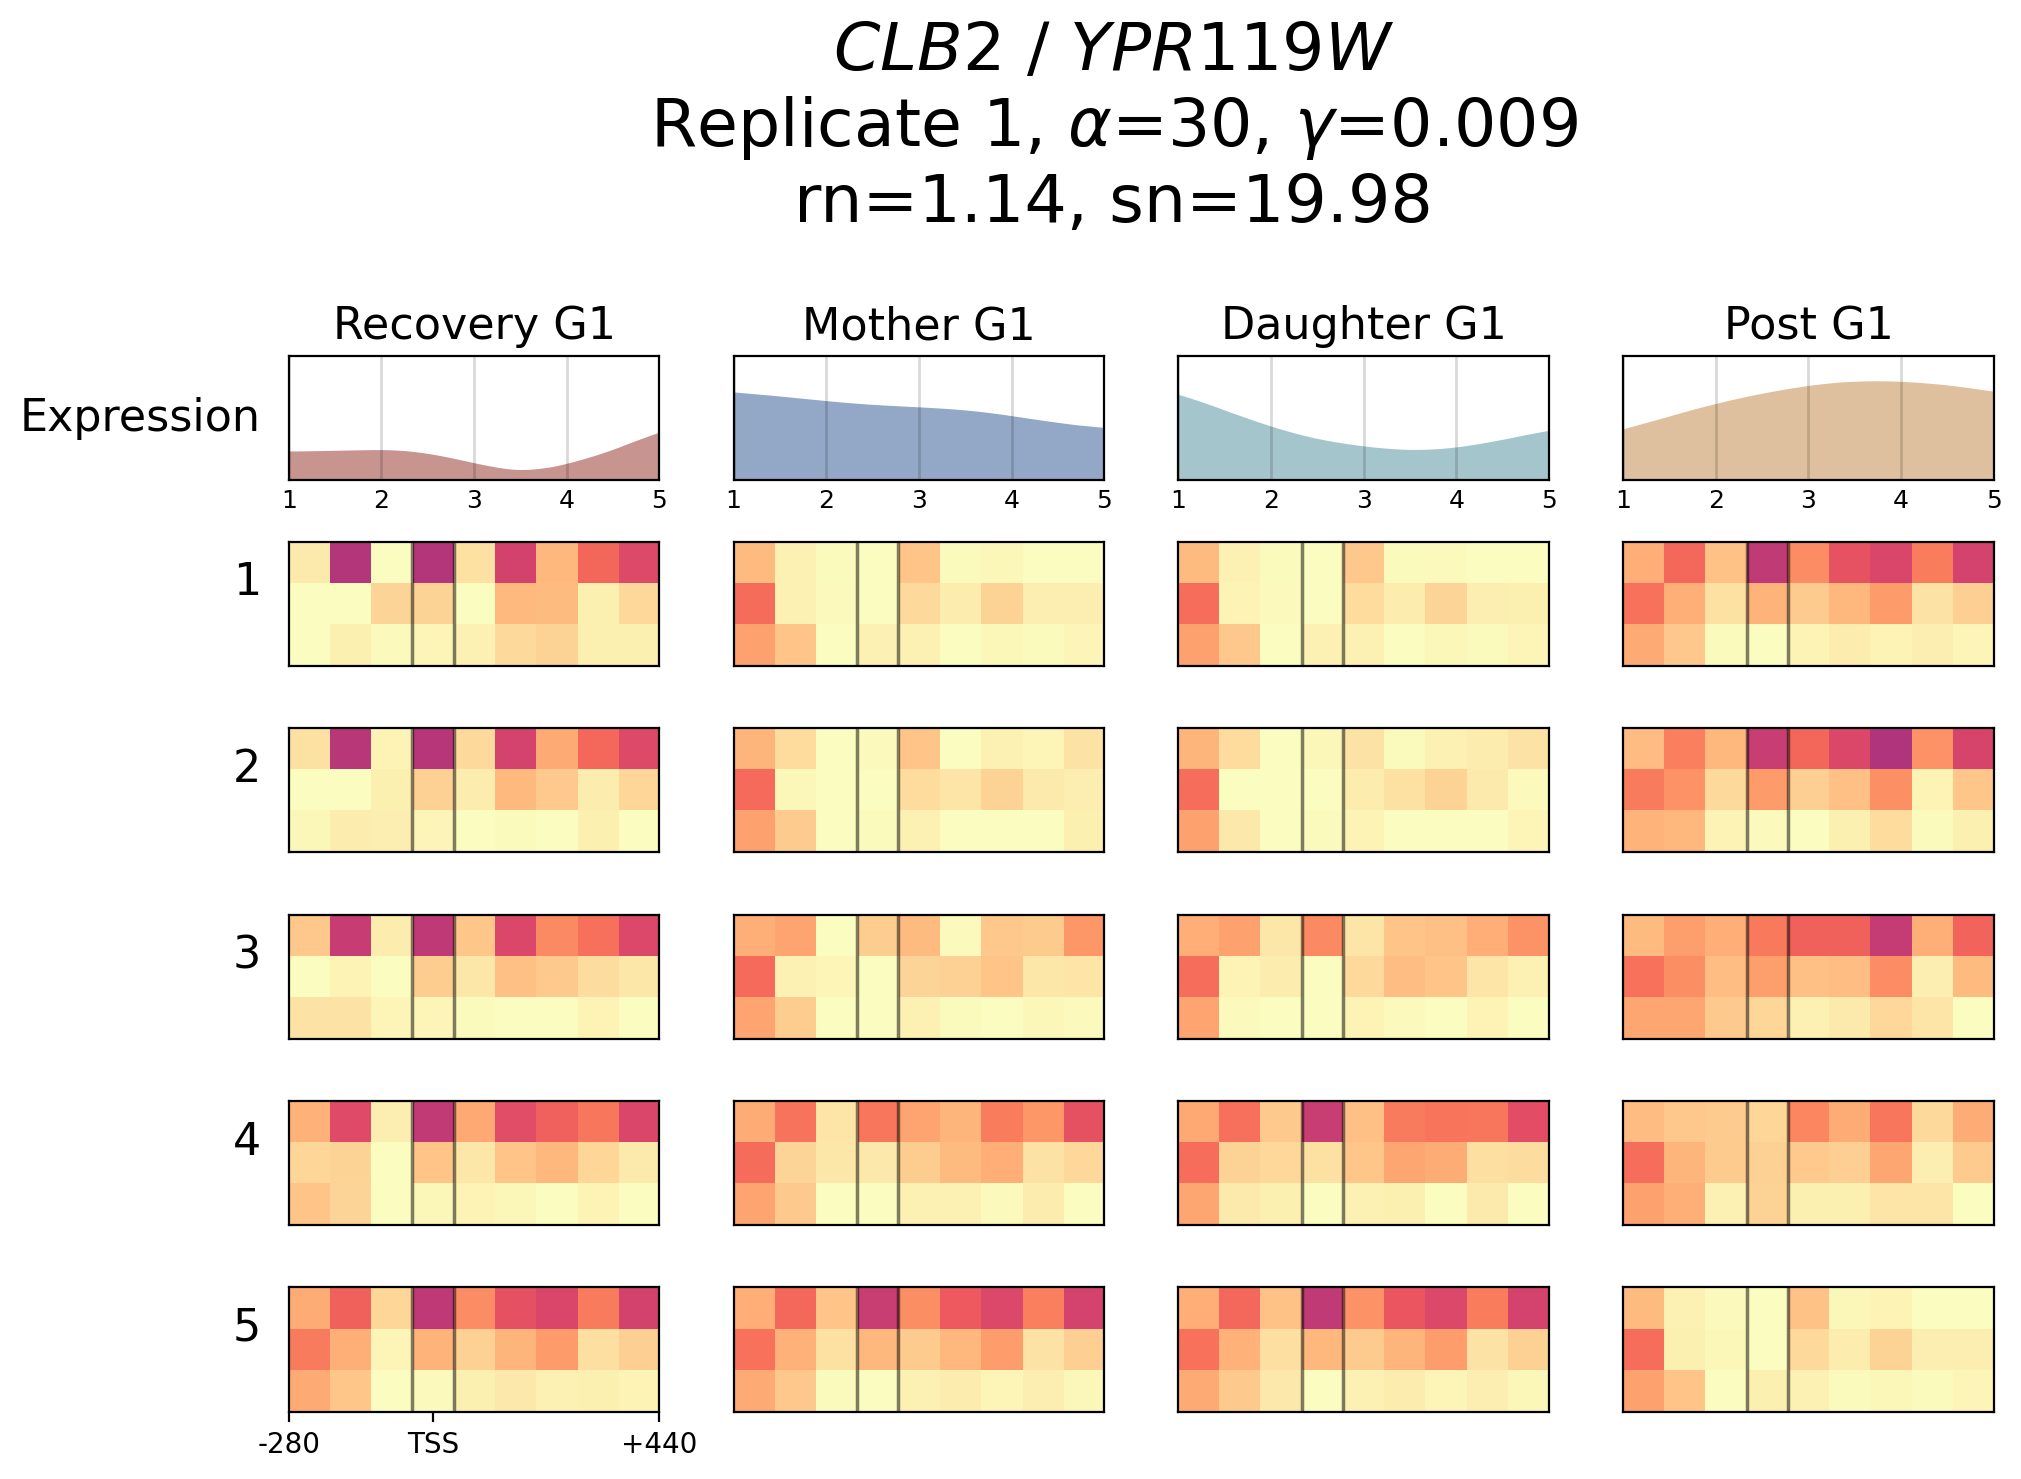

In [273]:
chrom1_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model1)

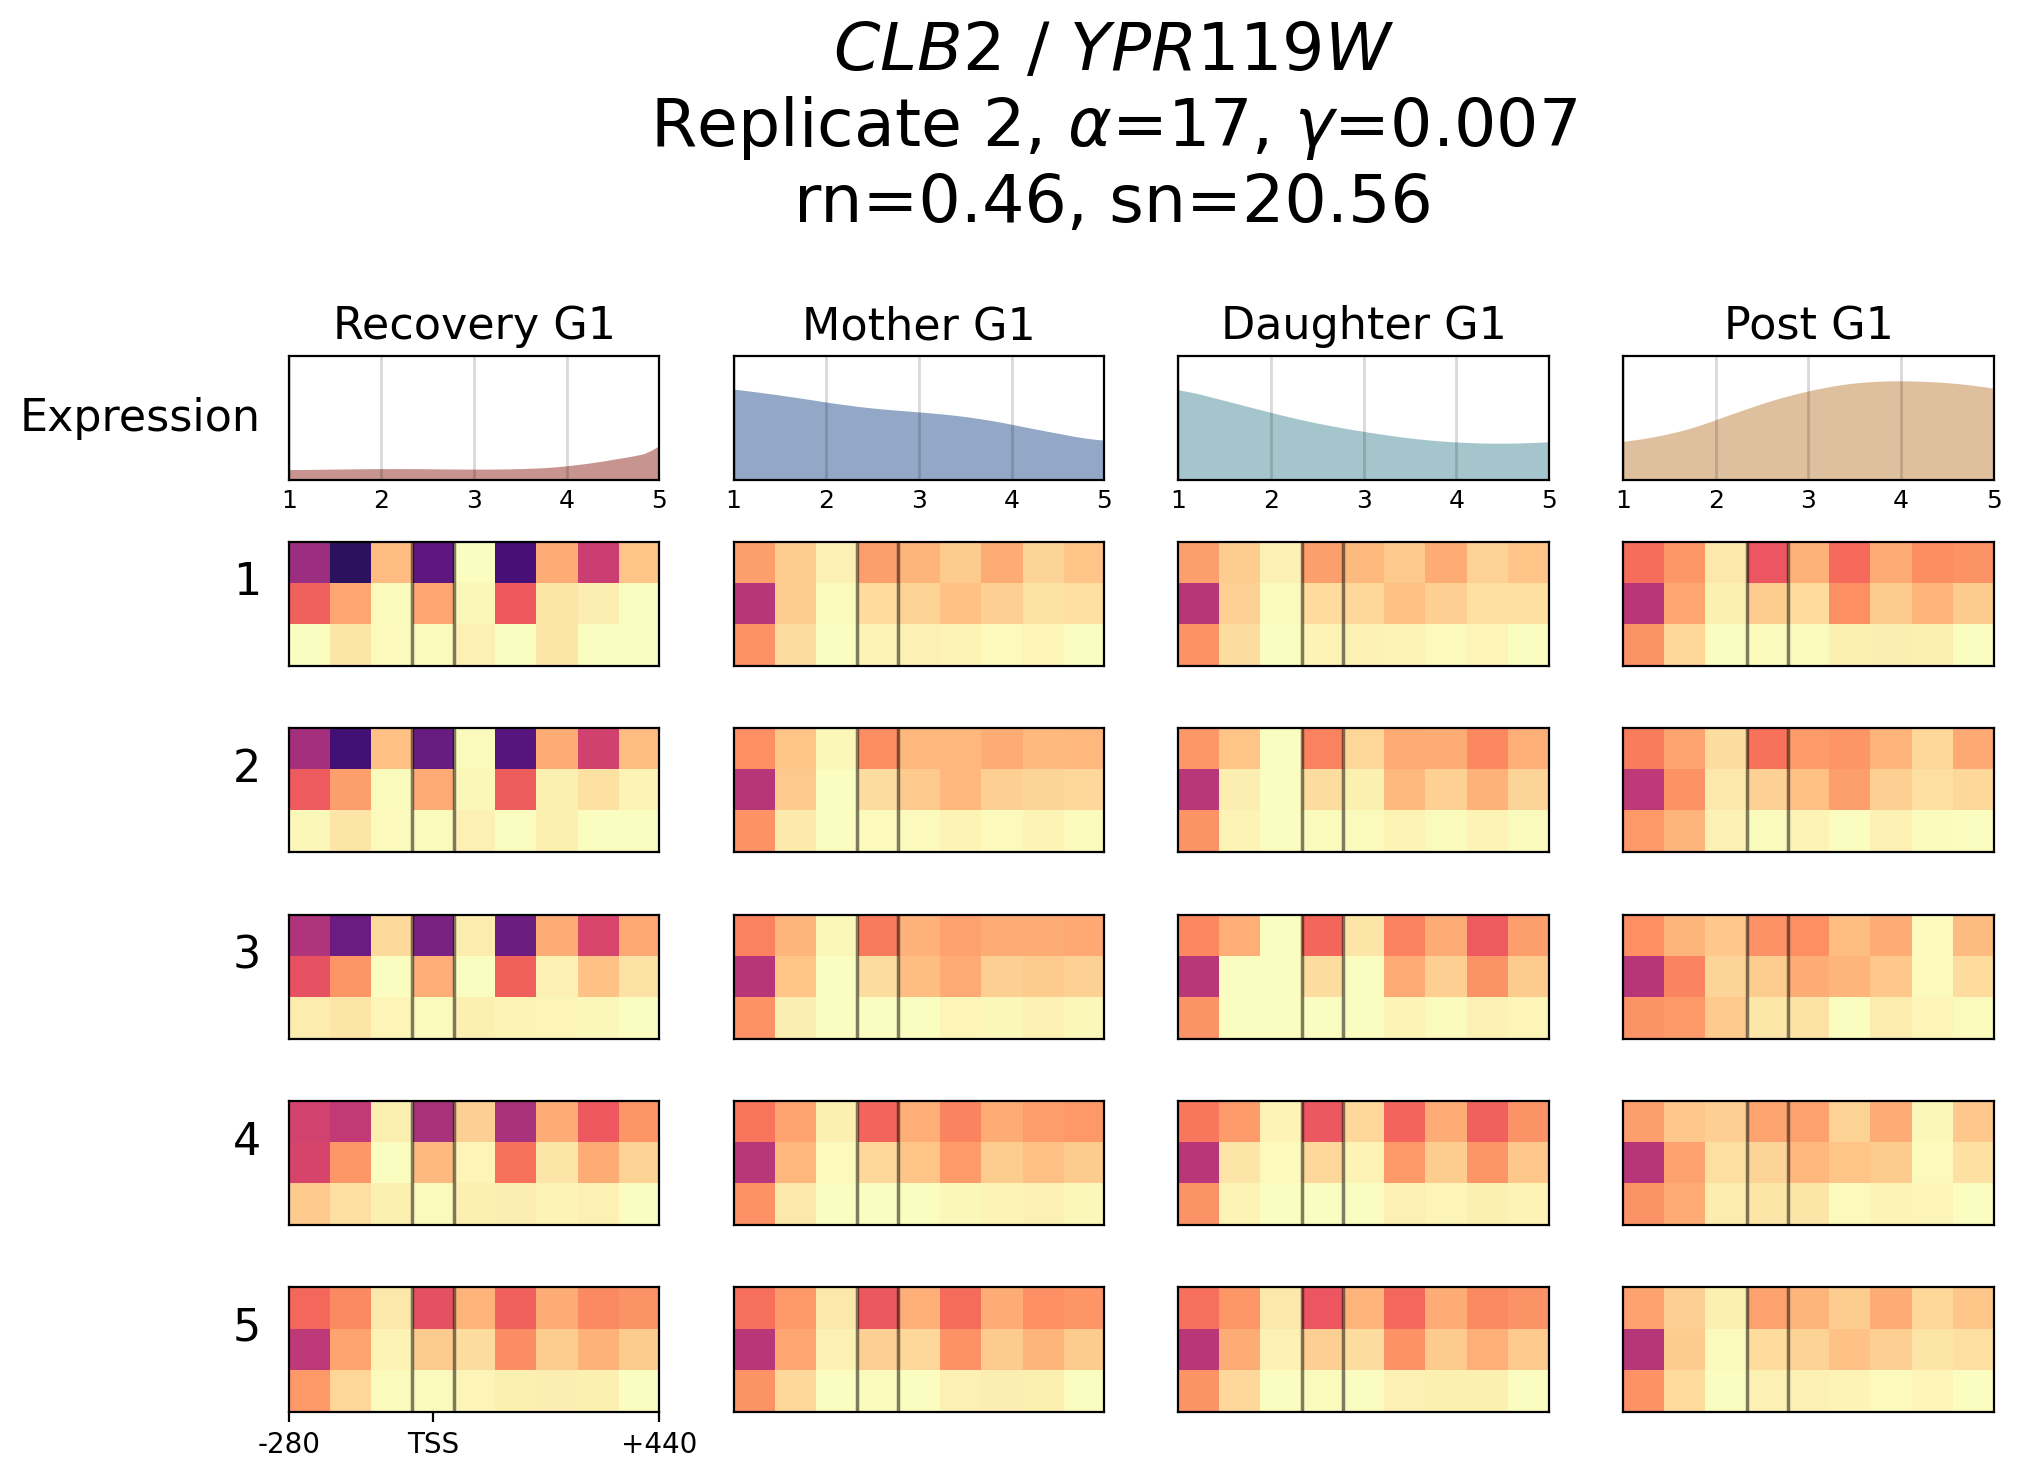

In [274]:
chrom2_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model2)

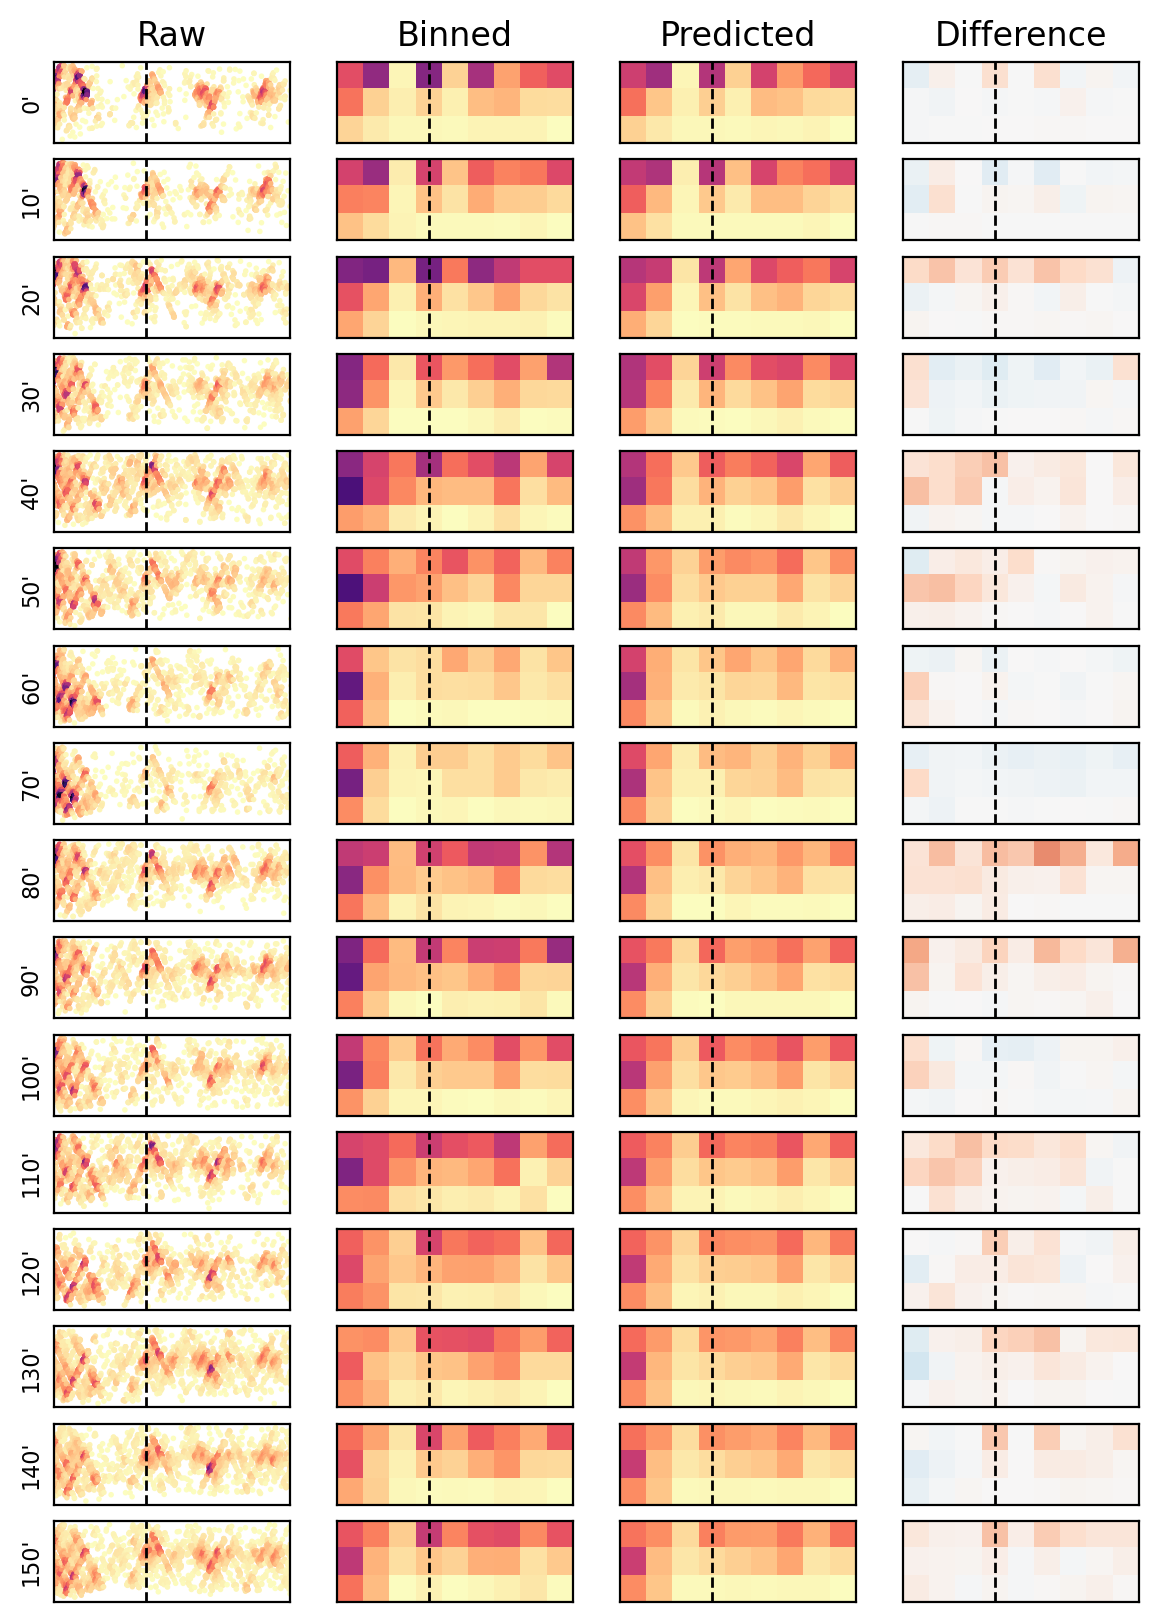

In [275]:
chrom1_model.plot_prediction_comparison()

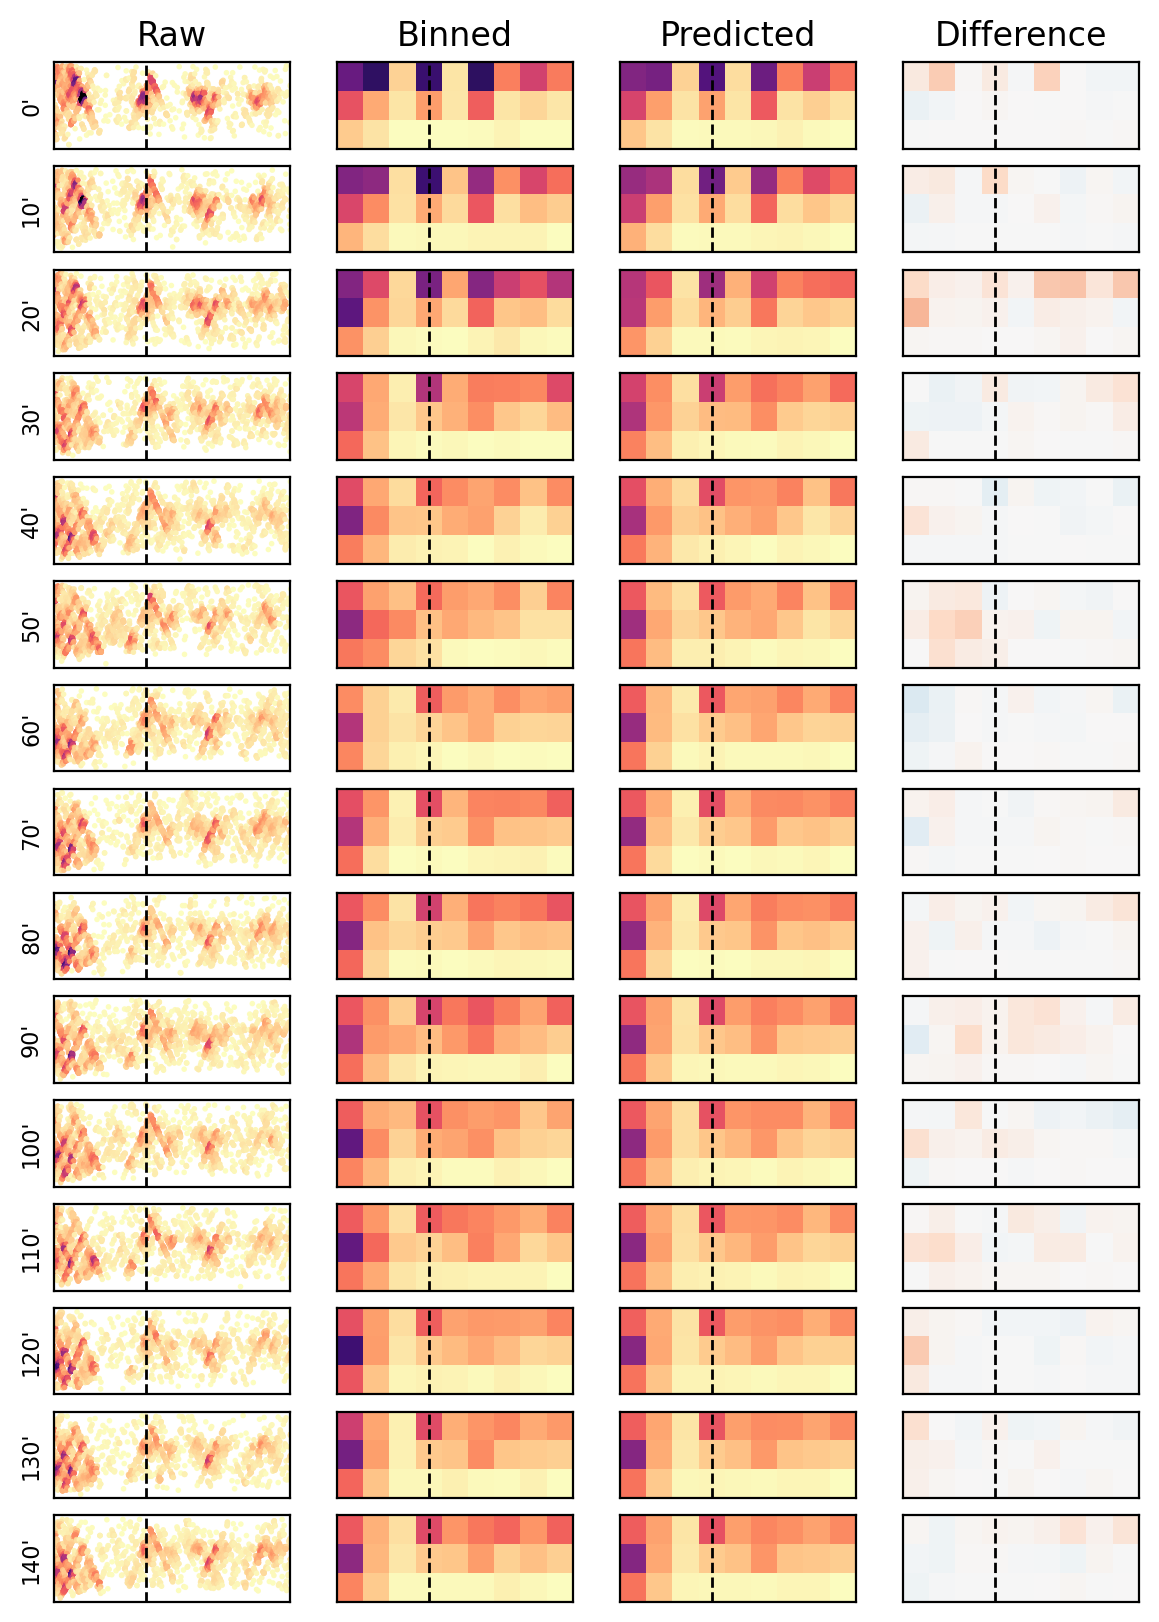

In [276]:
chrom2_model.plot_prediction_comparison()